---

# Part 3. Speculative Decoding 기초

Autoregressive decoding은 토큰 하나를 뽑을 때마다 모델 전체 weight를 한 번씩 읽어야 합니다.
배치가 1일 때 GPU 연산 유닛은 거의 놀고 있고, **메모리 대역폭만 소진**됩니다.

Speculative Decoding(SD)의 아이디어:

1. **Draft** — 값싼 모델이 앞으로 나올 $\gamma$개 토큰을 추측한다.
2. **Verify** — target 모델이 그 $\gamma$개를 **한 번의 forward로 동시에** 채점한다.
3. 앞에서부터 일치하는 만큼 받아들이고, 처음 틀린 자리에는 **target 자신의 예측**을 넣는다.

3번 때문에 SD는 **lossless**입니다. greedy decoding이라면 출력이 AR decoding과 **토큰 단위로 완전히 동일**합니다.
(샘플링에서는 rejection sampling으로 target 분포가 정확히 보존됩니다.)
Quantization/Pruning과 성질이 근본적으로 다른 지점입니다.

속도 모델은 다음과 같습니다.

$$
\text{speedup} \approx \frac{\tau}{1 + c\,\gamma}
$$

- $\tau$ : 라운드당 평균 수락 토큰 수 (acceptance length)
- $c$ : target 대비 drafter의 비용 비율

**$\tau$만 키우면 되는 것이 아니라 drafting 비용이 분모에 있다** — 이 식이 Part 4, 5 전체를 관통합니다.

In [ ]:
import os
import torch
import transformers
import math
import matplotlib.pyplot as plt
import random
import torch.nn.functional as F
import time

from transformers import AutoTokenizer, AutoModelForCausalLM

DEVICE = "cuda"
DTYPE = torch.float16

print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.get_device_name(0))

In [ ]:
# =====================================================================
# 실습에 사용할 모델 다운로드
# =====================================================================

import os
from huggingface_hub import snapshot_download

MODEL_ROOT = "/content/models"
os.makedirs(MODEL_ROOT, exist_ok=True)

MODEL_PATHS = {
    "target": {
        "repo": "Qwen/Qwen3-4B",
        "path": f"{MODEL_ROOT}/Qwen3-4B",
    },
    "vanilla_draft": {
        "repo": "Qwen/Qwen3-0.6B",
        "path": f"{MODEL_ROOT}/Qwen3-0.6B",
    },
    "eagle3_draft": {
        "repo": "AngelSlim/Qwen3-4B_eagle3",
        "path": f"{MODEL_ROOT}/Qwen3-4B_eagle3",
    },
    "dflash_draft": {
        "repo": "z-lab/Qwen3-4B-DFlash-b16",
        "path": f"{MODEL_ROOT}/Qwen3-4B-DFlash-b16",
    },
}

for name, info in MODEL_PATHS.items():
    print(f"Downloading {name}...")

    snapshot_download(
        repo_id=info["repo"],
        local_dir=info["path"],
    )

print("\nAll models downloaded.")

In [ ]:
# =====================================================================
# 3-0. Target / Draft 모델 로드
# =====================================================================

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

TARGET_DIR = "/content/models/Qwen3-4B"
DRAFT_DIR  = "/content/models/Qwen3-0.6B"

DTYPE = torch.float16

# Tokenizer
sd_tokenizer = AutoTokenizer.from_pretrained(TARGET_DIR)

# Target model
target_model = AutoModelForCausalLM.from_pretrained(
    TARGET_DIR,
    dtype=DTYPE,
    attn_implementation="sdpa",
).to(DEVICE).eval()

# Draft model
draft_model = AutoModelForCausalLM.from_pretrained(
    DRAFT_DIR,
    dtype=DTYPE,
    attn_implementation="sdpa",
).to(DEVICE).eval()

EOS = sd_tokenizer.eos_token_id

print("Target :", TARGET_DIR)
print("Draft  :", DRAFT_DIR)
print(f"VRAM   : {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

In [ ]:
# =====================================================================
# 3-1. 평가용 프롬프트와 AR Baseline
# =====================================================================

PROMPT = "Write a Python function that reverses a linked list."
MAX_NEW = 128
EOS = sd_tokenizer.eos_token_id

ids = sd_tokenizer.apply_chat_template(
  [{"role": "user", "content": PROMPT}],
  tokenize=True,
  add_generation_prompt=True,
  enable_thinking=False,
  return_tensors="pt",
  return_dict=True
)["input_ids"].to(DEVICE)


# ---------------------------------------------------------------------
# 한 token을 생성하는 공통 함수
# ---------------------------------------------------------------------

@torch.inference_mode()
def greedy_step(model, token, cache):

  out = model(
    token,
    past_key_values=cache,
    use_cache=True
  )

  next_token = out.logits[:, -1].argmax(-1, keepdim=True)

  return next_token, out.past_key_values


# ---------------------------------------------------------------------
# AR Baseline
# ---------------------------------------------------------------------

@torch.inference_mode()
def greedy_decode(model, ids, max_new_tokens):
  output = ids.clone()

  # 마지막 prompt token 직전까지 Prefill
  prefix = ids[:, :-1]
  cache = model(prefix, use_cache=True).past_key_values

  # 마지막 prompt token부터 Decode 시작
  token = ids[:, -1:]

  torch.cuda.synchronize()
  start = time.perf_counter()

  n_new = 0

  for _ in range(max_new_tokens):

    token, cache = greedy_step(
      model,
      token,
      cache
    )

    output = torch.cat([output, token], dim=-1)
    n_new += 1

    if token.item() == EOS:
      break

  torch.cuda.synchronize()
  decode_time = time.perf_counter() - start

  return output, decode_time, n_new

In [ ]:
# =====================================================================
# AR Baseline 실행: Decode-only TPS
# =====================================================================

ar_out, decode_time, decode_tokens = greedy_decode(
  target_model,
  ids,
  MAX_NEW
)

ar_tps = decode_tokens / decode_time

text = sd_tokenizer.decode(
  ar_out[0, ids.shape[1]:],
  skip_special_tokens=True
)

print(f"[AR Decode] {decode_tokens} tokens / {decode_time:.2f}s = {ar_tps:.1f} tok/s")
print(text)

## [실습 4] Vanilla Speculative Decoding 구현

한 라운드의 흐름입니다. (`n_committed` = 현재까지 확정된 토큰 수)

```
draft : d1, d2, ..., dγ 를 순차적으로 γ번 forward 하여 생성
target: [마지막 확정 토큰, d1, ..., dγ] 를 한 번의 forward로 처리
        -> preds[0..γ] 를 얻음 (preds[j] = d1..dj 를 봤을 때 target의 다음 토큰 예측)
accept: preds[j] == d_{j+1} 인 동안 전진, n개 수락
commit: d1..dn  +  preds[n]   (마지막 하나는 target 자신의 토큰이므로 항상 정답)
cache : 두 캐시를 모두 n_committed + n 길이로 롤백
```

**주의**: 라운드마다 최소 1개(`preds[n]`)는 반드시 확정되므로 무한 루프가 생기지 않습니다.
캐시 롤백(`crop_cache`)을 빠뜨리면 이후 출력이 깨지므로 반드시 넣어야 합니다.

In [ ]:
# =====================================================================
# 3-2. Draft Generation
# =====================================================================

@torch.inference_mode()
def draft_tokens(model, x, cache, gamma):
  tokens = []

  ######################### 실습 시작 ########################

  # TODO: 다음 draft token을 생성하세요.
  # HINT: greedy_step()을 사용해 draft token을 gamma개 순차적으로 생성하세요.
  for _ in range( ):
    x, cache =
    tokens.append(x)

  ######################### 실습 끝 ########################

  return torch.cat(tokens, dim=-1), cache


# =====================================================================
# 3-3. Target Verification
# =====================================================================

@torch.inference_mode()
def verify_draft(target, x, drafted, cache):

  ######################### 실습 시작 ########################

  # TODO : 마지막 committed token과 draft token들을 하나의 sequence로 연결하세요.
  # HINT: torch.cat()을 사용해 마지막 committed token과 draft token들을 sequence 방향으로 연결하세요.
  verify_ids =

  result = target(
    verify_ids,
    past_key_values=cache,
    use_cache=True
  )

  preds = result.logits[0].argmax(-1)

  ######################### 실습 끝 ########################

  return preds, result.past_key_values

In [ ]:
# =====================================================================
# 3-4. Accept / Reject
# =====================================================================

def accept_draft(drafted, preds, gamma):

  ######################### 실습 시작 ########################

  #TODO: Draft와 Target prediction을 앞에서부터 비교하고 첫 mismatch에서 멈추세요.
  n = 0
  for i in range(gamma):
    if
      n += 1
    else:
      break

  # accept된 draft token 뒤에 Target의 prediction 하나를 추가
  new_tokens = torch.cat([drafted[:, :n],preds[n].view(1, 1)],dim=1)

  ######################### 실습 끝 ########################

  return new_tokens, n

In [ ]:
# =====================================================================
# 3-5. Speculative Decoding
# =====================================================================

@torch.inference_mode()
def speculative_decode(target, draft, ids, gamma=4, max_new_tokens=MAX_NEW):
  out = ids.clone()

  # Prefill
  prefix = ids[:, :-1]
  tc = target(prefix, use_cache=True).past_key_values
  dc = draft(prefix, use_cache=True).past_key_values

  n_new, rounds = 0, 0

  torch.cuda.synchronize()
  start = time.perf_counter()

  while n_new < max_new_tokens:

    # 1) Draft
    x = out[:, dc.get_seq_length():]
    drafted, dc = draft_tokens(draft, x, dc, gamma)

    # 2) Verify
    x = out[:, tc.get_seq_length():]
    preds, tc = verify_draft(target, x, drafted, tc)

    # 3) Accept / Reject
    new_tokens, n = accept_draft(drafted, preds, gamma)

    # 생성 길이 제한
    new_tokens = new_tokens[:, :max_new_tokens - n_new]
    out = torch.cat([out, new_tokens], dim=1)

    n_new += new_tokens.shape[1]
    rounds += 1

    # Reject된 token의 KV 제거
    keep_len = out.shape[1] - 1

    for cache in (tc, dc):
      if cache.get_seq_length() > keep_len:
        cache.crop(keep_len - cache.get_seq_length())

    if (new_tokens == EOS).any():
      break

  torch.cuda.synchronize()
  decode_time = time.perf_counter() - start

  return out, n_new / rounds, rounds, decode_time

In [ ]:
# =====================================================================
# 3-6. AR vs Speculative Decoding
# =====================================================================

GAMMA = 4

# 1) Autoregressive Decoding
ar_out, ar_time, ar_tokens = greedy_decode(
  target_model,
  ids,
  MAX_NEW
)

ar_tps = ar_tokens / ar_time


# 2) Speculative Decoding
sd_out, tau, rounds, sd_time = speculative_decode(
  target_model,
  draft_model,
  ids,
  gamma=GAMMA,
  max_new_tokens=MAX_NEW
)

sd_tokens = sd_out.shape[1] - ids.shape[1]
sd_tps = sd_tokens / sd_time


# 3) 결과 비교
print(f"Gamma            : {GAMMA}")
print(f"AR TPS           : {ar_tps:.1f} tok/s")
print(f"SD TPS           : {sd_tps:.1f} tok/s")
print(f"Speedup          : {sd_tps / ar_tps:.2f}x")
print(f"Avg tokens/round : {tau:.2f}")
print(f"Target rounds    : {rounds}")
print(f"Identical output : {torch.equal(ar_out, sd_out)}")

print("\n[Output]")
print(
  sd_tokenizer.decode(
    sd_out[0, ids.shape[1]:],
    skip_special_tokens=True
  )
)

Gamma            : 4
AR TPS           : 18.0 tok/s
SD TPS           : 16.4 tok/s
Speedup          : 0.91x
Avg tokens/round : 3.76
Target rounds    : 34
Identical output : True

[Output]
Sure! Here's a Python function that reverses a **linked list**. We'll assume that the linked list is represented using a `Node` class, where each node has a `value` and a `next` pointer.

### Step 1: Define the Node class

```python
class Node:
    def __init__(self, value):
        self.value = value
        self.next = None
```

### Step 2: Define the function to reverse the linked list

```python
def reverse_linked_list(head):
    prev = None
    current = head

    while current:
        next_node = current


Gamma= 1 | Avg tokens/round=1.86 | TPS=19.6
Gamma= 2 | Avg tokens/round=2.51 | TPS=17.0
Gamma= 4 | Avg tokens/round=3.76 | TPS=16.9
Gamma= 6 | Avg tokens/round=4.57 | TPS=15.4
Gamma= 8 | Avg tokens/round=4.92 | TPS=12.2


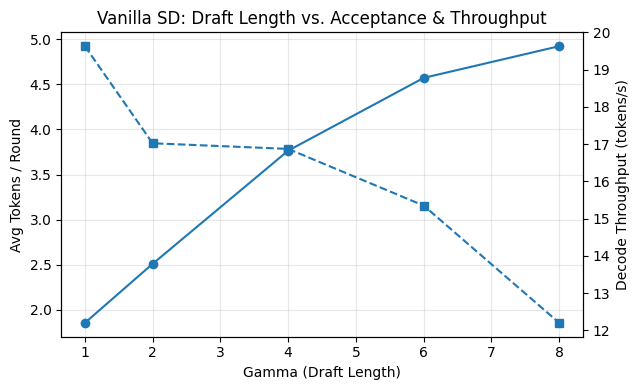

In [ ]:
# =====================================================================
# 3-7. Gamma Sweep: Avg Tokens/Round와 Decode TPS 비교
# =====================================================================

gammas = [1, 2, 4, 6, 8]

avg_tokens = []
tpss = []

for gamma in gammas:

  # Warm-up
  _ = speculative_decode(
    target_model,
    draft_model,
    ids,
    gamma=gamma,
    max_new_tokens=8
  )

  # Speculative Decoding 측정
  out, tau, rounds, decode_time = speculative_decode(
    target_model,
    draft_model,
    ids,
    gamma=gamma,
    max_new_tokens=MAX_NEW
  )

  n_new = out.shape[1] - ids.shape[1]
  tps = n_new / decode_time

  avg_tokens.append(tau)
  tpss.append(tps)

  print(
    f"Gamma={gamma:>2} | "
    f"Avg tokens/round={tau:.2f} | "
    f"TPS={tps:.1f}"
  )


# =====================================================================
# Plot
# =====================================================================

fig, ax1 = plt.subplots(figsize=(6.5, 4))

# Target verification 한 번당 확정되는 token 수
ax1.plot(gammas, avg_tokens, "o-")
ax1.set_xlabel("Gamma (Draft Length)")
ax1.set_ylabel("Avg Tokens / Round")
ax1.grid(alpha=0.3)

# Decode throughput
ax2 = ax1.twinx()
ax2.plot(gammas, tpss, "s--")
ax2.set_ylabel("Decode Throughput (tokens/s)")

plt.title("Vanilla SD: Draft Length vs. Acceptance & Throughput")
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# Part 3 종료: GPU 메모리 정리
# =====================================================================

import gc

if "target_model" in globals():
    del target_model

if "draft_model" in globals():
    del draft_model

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

VRAM after cleanup: 0.01 GB


---

# Part 4. EAGLE 계열: Tree Drafting

Vanilla SD는 draft를 **하나의 사슬(chain)** 로만 만듭니다. 중간에 한 번 틀리면 뒤는 전부 버려집니다.
EAGLE 계열은 대신 **여러 후보 경로를 트리로 묶어 한 번에 검증**합니다.

| | drafting 대상 | 트리 | 특징 |
|---|---|---|---|
| EAGLE-1 | feature(hidden state) 공간 | 정적 트리 | token 대신 feature를 예측 + shifted token으로 불확실성 보정 |
| EAGLE-2 | feature | **동적 트리** | drafter의 confidence로 문맥마다 다른 트리 구성 |
| EAGLE-3 | **다층 fused feature → token 직접 예측** | 동적 트리 | feature 예측 제약 제거, 학습 데이터 스케일링에 잘 반응 |

**트리 검증의 핵심 두 가지**

1. **Ancestor-only attention mask** — 트리의 모든 노드를 한 시퀀스로 펼쳐 넣되,
   각 노드는 자기 **조상 노드만** 볼 수 있어야 합니다. 형제/사촌을 보면 안 됩니다.
2. **노드별 position_ids** — 위치는 시퀀스에서의 순서가 아니라 **트리에서의 깊이**를 따릅니다.

> **본 실습의 범위**: EAGLE의 feature-level drafter는 별도 학습된 체크포인트가 필요합니다.
> 여기서는 drafter를 일반 소형 LM으로 대체하고, **채점 대상인 트리 구성/마스크/검증 로직**은
> 실제 EAGLE-2와 동일하게 구현합니다. 실제 체크포인트로 확장하려면
> `AngelSlim/Qwen3-4B_eagle3` + `github.com/SafeAILab/EAGLE`을 참고하세요.

## [실습 7-A] Tree attention mask와 position_ids

트리를 다음과 같이 표현합니다.

- `tokens[i]` : 노드 i의 토큰 id
- `parent[i]` : 부모 노드의 인덱스. `-1`이면 부모가 **prefix의 마지막 토큰(anchor)** 입니다.
- `depth[i]`  : 루트로부터의 깊이 (1부터 시작)
- 노드는 항상 **부모가 자식보다 먼저** 오도록 정렬되어 있습니다.

KV는 `[prefix 0..prefix_len-1] + [node 0..N-1]` 순서로 놓입니다.
additive mask이므로 **허용은 0.0, 금지는 dtype의 최솟값**을 넣습니다.

In [ ]:
# =====================================================================
# 4-0. EAGLE-3 Setup & Model Load
# =====================================================================

import os
import sys

EAGLE_DIR = "/content/EAGLE-practice"

TARGET_DIR = "/content/models/Qwen3-4B"
EAGLE_MODEL_DIR = "/content/models/Qwen3-4B_eagle3"

TREE_SIZE = 16


# EAGLE 코드 준비
if not os.path.exists(EAGLE_DIR):
  !git clone -q https://github.com/kimjongjip/EAGLE-practice.git

if EAGLE_DIR not in sys.path:
  sys.path.insert(0, EAGLE_DIR)

from eagle.model.ea_model import EaModel


# EAGLE-3 모델 로드
eagle_model = EaModel.from_pretrained(
  base_model_path=TARGET_DIR,
  ea_model_path=EAGLE_MODEL_DIR,
  use_eagle3=True,
  total_token=TREE_SIZE,
  depth=3,
  top_k=4,
  torch_dtype=DTYPE,
  device_map={"": DEVICE},
  attn_implementation="eager",
).eval()

tokenizer = eagle_model.get_tokenizer()


print("EAGLE-3 loaded")
print("Target :", TARGET_DIR)
print("EAGLE  :", EAGLE_MODEL_DIR)
print(f"Tree Size : {TREE_SIZE}")
print(f"VRAM      : {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

EAGLE-3 loaded
Target : /content/models/Qwen3-4B
EAGLE  : /content/models/Qwen3-4B_eagle3
Tree Size : 16
VRAM      : 8.65 GB


In [ ]:
# =====================================================================
# 4-1. 평가용 Prompt
# =====================================================================

PROMPT = "Write a Python function that reverses a linked list."
MAX_NEW = 128

text = tokenizer.apply_chat_template(
  [{"role": "user", "content": PROMPT}],
  tokenize=False,
  add_generation_prompt=True,
  enable_thinking=False
)

input_ids = tokenizer(
  text,
  return_tensors="pt",
  add_special_tokens=False
).input_ids.to(DEVICE)

print("Input length:", input_ids.shape[1])

Input length: 23


In [ ]:
# =====================================================================
# 4-2. EAGLE Draft Tree 관찰
# =====================================================================

from eagle.model.utils import initialize_tree

eagle_model.ea_layer.reset_kv()

# 실제 EAGLE drafter로 첫 Tree 생성
draft_tokens, retrieve_indices, tree_mask, tree_position_ids, *_ = (
  initialize_tree(
    input_ids,
    eagle_model,
    past_key_values=None,
    logits_processor=None
  )
)

retrieve_indices = retrieve_indices.to(draft_tokens.device)

children = {}

for path in retrieve_indices.tolist():
  path = [x for x in path if x >= 0]
  for parent, child in zip(path[:-1], path[1:]):
    if parent not in children:
      children[parent] = []
    if child not in children[parent]:
      children[parent].append(child)

def token_text(node):
  token_id = draft_tokens[0, node].item()
  return repr(tokenizer.decode([token_id]))


# ---------------------------------------------------------------------
# Tree 출력
# ---------------------------------------------------------------------

def print_tree(node, prefix=""):
  childs = children.get(node, [])
  for i, child in enumerate(childs):
    last = (i == len(childs) - 1)
    print(
      prefix
      + ("└── " if last else "├── ")
      + token_text(child)
    )
    print_tree(
      child,
      prefix + ("    " if last else "│   ")
    )


# ---------------------------------------------------------------------
# 결과
# ---------------------------------------------------------------------

print(f"Tree Nodes      : {draft_tokens.shape[1]}")
print(f"Candidate Paths : {retrieve_indices.shape[0]}")
print(f"Max Depth       : {tree_position_ids.max().item()}")

print("\n[Draft Tree]")
print(f"[root] {token_text(0)}")
print_tree(0)

eagle_model.ea_layer.reset_kv()

Tree Nodes      : 16
Candidate Paths : 6
Max Depth       : 4

[Draft Tree]
[root] 'Sure'
├── '!'
│   ├── ' Here'
│   │   ├── ' Python'
│   │   ├── 'Here'
│   │   │   └── "'s"
│   │   ├── 'Sure'
│   │   │   └── "'s"
│   │   └── "'s"
│   │       └── ' Python'
│   └── ' Below'
│       └── ' Python'
└── 'ly'
    └── 'ly'
        └── 'ly'
            └── 'ly'


In [ ]:
# =====================================================================
# 4-3. [실습 1] Tree Attention Mask
# =====================================================================

import eagle.model.student_tree as student_tree

def build_tree_mask_and_positions(
  mask_index_list,
  total_tokens,
  device=None
):
  # 자기 자신은 항상 볼 수 있음
  tree_mask = torch.eye(
    total_tokens + 1,
    dtype=torch.bool,
    device=device
  )
  tree_mask[:, 0] = True

  ######################### 실습 시작 ########################

  # ToDo: child가 parent가 볼 수 있는 node들을 그대로 볼 수 있게 하세요.
  # |= 는 OR 결과를 왼쪽에 저장하는 연산입니다.
  for child, parent in enumerate(mask_index_list, start=1):


  ######################### 실습 끝 ########################

  # 보이는 node 수를 이용해 Tree depth 계산
  tree_position_ids = tree_mask.sum(dim=1).long() - 1
  tree_mask = tree_mask.float()[None, None]
  return tree_mask, tree_position_ids

# 구현을 실제 EAGLE에 연결
student_tree.build_tree_mask_and_positions = build_tree_mask_and_positions

In [ ]:
mask, positions = build_tree_mask_and_positions(
  [0, 0, 1],
  total_tokens=3,
  device="cpu"
)

print("[Tree Mask]")
print(mask[0, 0].int())

print("\nPosition IDs:", positions.tolist())

[Tree Mask]
tensor([[1, 0, 0, 0],
        [1, 1, 0, 0],
        [1, 0, 1, 0],
        [1, 1, 0, 1]], dtype=torch.int32)

Position IDs: [0, 1, 1, 2]


In [ ]:
# =====================================================================
# 4-4. [실습 2] Tree Verification
# =====================================================================

import eagle.model.ea_model as ea_module

def tree_decoding(
  model,
  tree_candidates,
  past_key_values,
  tree_position_ids,
  input_ids,
  retrieve_indices,
):
  position_ids = tree_position_ids + input_ids.shape[1]
  if position_ids.dim() == 1:
    position_ids = position_ids.unsqueeze(0)


  ######################### 실습 시작 ########################

  # To Do: Tree candidate 전체를 Target model에 한 번에 입력하세요.
  outputs, tree_logits, hidden_state = model(  )

  ######################### 실습 끝 ########################

  # 아래 부분은 EAGLE-3 내부 처리를 위해 제공
  if model.use_eagle3:
    device = model.ea_layer.lm_head.weight.device
    states = [x.to(device) for x in outputs["hidden_states"]]
    hidden_state = torch.cat(states, dim=-1)
  logits = tree_logits[0, retrieve_indices]

  return logits, hidden_state, outputs


# 구현을 EAGLE에 연결
ea_module.tree_decoding = tree_decoding

In [ ]:
# =====================================================================
# 4-5. [실습 3] Tree Acceptance
# =====================================================================

def evaluate_posterior(
  logits,
  candidates,
  logits_processor,
):

  # 본 실습에서는 Greedy Decoding만 사용
  assert logits_processor is None

  # 각 branch에서 Draft와 Target prediction 비교
  matches = (
    candidates[:, 1:].to(logits.device)
    == logits[:, :-1].argmax(dim=-1)
  ).int()

  # 첫 mismatch 전까지 연속으로 맞은 token 수
  accept_lengths = torch.cumprod(
    matches,
    dim=1
  ).sum(dim=1)


  ######################### 실습 시작 ########################

  # To Do: 가장 길게 일치한 branch와 그 accept length를 선택하세요.
  best_candidate =
  accept_length =

  ######################### 실습 끝 ########################

  sample_p = logits[
    best_candidate,
    accept_length
  ]

  return best_candidate, accept_length, sample_p


# 구현을 EAGLE에 연결
ea_module.evaluate_posterior = evaluate_posterior

In [ ]:
# =====================================================================
# 4-6. Full EAGLE-3 Generation
# =====================================================================

# Warm-up
_ = eagle_model.eagenerate(
  input_ids,
  temperature=0.0,
  max_new_tokens=8,
  max_length=256
)


# EAGLE-3 Generation
torch.cuda.synchronize()
start = time.perf_counter()

output_ids, n_new, last_round = eagle_model.eagenerate(
  input_ids,
  temperature=0.0,
  max_new_tokens=MAX_NEW,
  max_length=256,
  log=True
)

torch.cuda.synchronize()
elapsed = time.perf_counter() - start


# 결과 계산
if torch.is_tensor(n_new):
  n_new = n_new.item()

generated = output_ids.shape[1] - input_ids.shape[1]
rounds = last_round + 1

avg_tokens = n_new / rounds
tps = generated / elapsed


# 결과 출력
print(f"Generated Tokens : {generated}")
print(f"Target Rounds    : {rounds}")
print(f"Avg Tokens/Round : {avg_tokens:.2f}")
print(f"E2E TPS          : {tps:.1f} tok/s")

print("\n[Output]")
print(
  tokenizer.decode(
    output_ids[0, input_ids.shape[1]:],
    skip_special_tokens=True
  )
)

Generated Tokens : 129
Target Rounds    : 35
Avg Tokens/Round : 3.69
E2E TPS          : 26.5 tok/s

[Output]
Sure! Here's a Python function that reverses a **linked list**. We'll assume that the linked list is represented using a `Node` class, where each node has a `value` and a `next` pointer.

### Step 1: Define the Node class

```python
class Node:
    def __init__(self, value):
        self.value = value
        self.next = None
```

### Step 2: Define the function to reverse the linked list

```python
def reverse_linked_list(head):
    prev = None
    current = head

    while current:
        next_node = current.next


Depth=1 | Tree Size= 8 | Avg Tokens/Round=2.65 | TPS=40.4
Depth=2 | Tree Size=12 | Avg Tokens/Round=3.23 | TPS=46.4
Depth=3 | Tree Size=16 | Avg Tokens/Round=3.39 | TPS=39.3
Depth=4 | Tree Size=24 | Avg Tokens/Round=3.58 | TPS=47.5
Depth=5 | Tree Size=48 | Avg Tokens/Round=3.69 | TPS=44.7


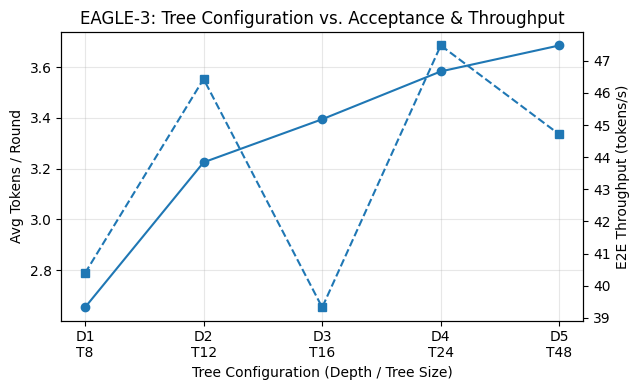

In [ ]:
# =====================================================================
# 4-7. Tree Configuration Sweep
#      Depth / Tree Size에 따른 EAGLE 성능 비교
# =====================================================================

configs = [
  (1, 8),
  (2, 12),
  (3, 16),
  (4, 24),
  (5, 48)
]

labels = []
avg_tokens_list = []
tpss = []


for depth, tree_size in configs:

  # EAGLE Tree 설정 변경
  eagle_model.ea_layer.depth = depth

  # ea_layer 내부에서는 root를 제외한 draft node 수를 사용
  eagle_model.ea_layer.total_tokens = tree_size - 1

  # Tree 관련 상태 초기화
  eagle_model.ea_layer.init_tree()
  eagle_model.ea_layer.reset_kv()


  # Warm-up
  _ = eagle_model.eagenerate(
    input_ids,
    temperature=0.0,
    max_new_tokens=8,
    max_length=256
  )


  # Generation 측정
  torch.cuda.synchronize()
  start = time.perf_counter()

  output_ids, n_new, last_round = eagle_model.eagenerate(
    input_ids,
    temperature=0.0,
    max_new_tokens=MAX_NEW,
    max_length=256,
    log=True
  )

  torch.cuda.synchronize()
  elapsed = time.perf_counter() - start


  if torch.is_tensor(n_new):
    n_new = n_new.item()

  generated = output_ids.shape[1] - input_ids.shape[1]
  rounds = last_round + 1

  avg_tokens = n_new / rounds
  tps = generated / elapsed


  labels.append(f"D{depth}\nT{tree_size}")
  avg_tokens_list.append(avg_tokens)
  tpss.append(tps)


  print(
    f"Depth={depth} | "
    f"Tree Size={tree_size:>2} | "
    f"Avg Tokens/Round={avg_tokens:.2f} | "
    f"TPS={tps:.1f}"
  )

# =====================================================================
# Plot
# =====================================================================

x = range(len(configs))

fig, ax1 = plt.subplots(figsize=(6.5, 4))

# 한 Target round에서 확정되는 평균 token 수
ax1.plot(x, avg_tokens_list, "o-")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_xlabel("Tree Configuration (Depth / Tree Size)")
ax1.set_ylabel("Avg Tokens / Round")
ax1.grid(alpha=0.3)

# Throughput
ax2 = ax1.twinx()
ax2.plot(x, tpss, "s--")
ax2.set_ylabel("E2E Throughput (tokens/s)")

plt.title("EAGLE-3: Tree Configuration vs. Acceptance & Throughput")
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================================
# Part 4 종료: GPU 메모리 정리
# =====================================================================

import gc

del eagle_model

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

VRAM after cleanup: 0.01 GB


### 관찰

트리를 키우면 $\tau$는 계속 올라가지만 speedup은 그만큼 따라오지 않습니다.
EAGLE 계열의 구조적 한계 때문입니다.

> **깊이를 1 늘릴 때마다 drafter forward가 한 번씩 더 필요합니다.**
> drafting은 여전히 autoregressive이고, 이 sequential 비용이 앞의 속도 식에서 분모를 키웁니다.

"그럼 블록 전체를 **한 번의 forward로** 뽑으면 되지 않나?" — 이것이 다음 파트의 출발점입니다.

# Part 5. DFlash: Parallel Block Drafting [ICML'26]

DFlash는 **block diffusion drafter**를 사용해 여러 미래 토큰을 **한 번의 forward로 병렬 생성**합니다.

* Vanilla SD: draft token을 autoregressive하게 순차 생성
* EAGLE: 여러 candidate를 tree 형태로 생성
* **DFlash: block 전체의 token을 동시에 생성**

```text
[MASK] [MASK] [MASK] [MASK]
          ↓
   DFlash Forward × 1
          ↓
    d1    d2    d3    d4
          ↓
   Target Verification
```

Target은 draft block 전체를 한 번에 검증하고, **앞에서부터 일치하는 prefix만 accept**하므로 최종 결과는 lossless하게 유지됩니다.

본 실습에서는 실제 `Qwen/Qwen3-4B`와 `z-lab/Qwen3-4B-DFlash-b16`을 사용하여 **parallel block drafting과 verification을 구현**하고, Block Size에 따른 **Acceptance Length와 TPS 변화**를 비교합니다.


In [ ]:
# =====================================================================
# 5-0. DFlash Setup & Model Load
# =====================================================================

import os
import sys

DFLASH_DIR = "/content/dflash-practice"

TARGET_DIR = "/content/models/Qwen3-4B"
DFLASH_MODEL_DIR = "/content/models/Qwen3-4B-DFlash-b16"


# DFlash 코드 준비
if not os.path.exists(DFLASH_DIR):
  !git clone -q https://github.com/kimjongjip/dflash-practice.git

if DFLASH_DIR not in sys.path:
  sys.path.insert(0, DFLASH_DIR)


from dflash.model import dflash_generate
from dflash.practice import (
  load_practice_models,
  stop_token_ids,
  apply_practice_chat_template,
)


# Target / DFlash 모델 로드
target, draft, tokenizer = load_practice_models(
  target_id=TARGET_DIR,
  draft_id=DFLASH_MODEL_DIR,
  device=DEVICE,
  dtype=DTYPE,
)


print("DFlash loaded")
print("Target :", TARGET_DIR)
print("Draft  :", DFLASH_MODEL_DIR)
print("Block  :", draft.block_size)
print("dtype  :", target.dtype)
print(f"VRAM   : {torch.cuda.memory_allocated()/1024**3:.2f} GB")

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/58 [00:00<?, ?it/s]

DFlash loaded
Target : /content/models/Qwen3-4B
Draft  : /content/models/Qwen3-4B-DFlash-b16
Block  : 16
dtype  : torch.float16
VRAM   : 8.62 GB


#DFlash의 Block Diffusion Drafting
Vanilla speculative decoding은 draft token을 autoregressive하게 하나씩 생성합니다.
DFlash는 미래 block을 [MASK] token으로 초기화하고, Target hidden state를 context로 사용하여 모든 masked position을 한 번의 denoising forward에서 동시에 예측합니다.

known | [MASK] | [MASK] | ... → DFlash → d1 | d2 | ...

In [ ]:
# =====================================================================
# 5-1. [실습] Parallel Block Drafting
#   한 번의 DFlash forward로 여러 draft token을 동시에 생성합니다.
# =====================================================================

import dflash.student_block as student_block


def parallel_block_draft(
  model,
  target_hidden,
  noise_embedding,
  draft_position_ids,
  past_key_values_draft,
  output_head,
  verify_size,
):

  global LAST_DRAFT

  # DFlash drafter를 한 번만 forward
  draft_hidden = model(
    target_hidden=target_hidden,
    noise_embedding=noise_embedding,
    position_ids=draft_position_ids,
    past_key_values=past_key_values_draft,
    use_cache=True,
  )

  # 실제로 제안할 draft token 수
  num_draft = verify_size - 1


  ######################### 실습 시작 ########################

  # To Do: 마지막 num_draft개의 hidden state만 선택하세요.
  draft_hidden =

  # To Do: model.compute_logits()을 사용해 모든 위치의 vocabulary logits을 계산하세요.
  draft_logits =

  # To Do: torch.argmax()를 사용해 모든 위치의 token을 동시에 선택하세요.
  draft_tokens =

  ######################### 실습 끝 ########################

  # 첫 번째 draft block만 저장
  if LAST_DRAFT is None:
    LAST_DRAFT = draft_tokens.detach().clone()

  return draft_tokens

  return draft_tokens


# 구현을 DFlash generation에 연결
student_block.parallel_block_draft = parallel_block_draft

In [ ]:
# =====================================================================
# 5-2. Parallel Draft 결과 확인
# =====================================================================

PROMPT = "Write a Python function that reverses a linked list."

text = apply_practice_chat_template(
  tokenizer,
  [{"role": "user", "content": PROMPT}]
)

input_ids = tokenizer(
  text,
  return_tensors="pt",
  add_special_tokens=False
).input_ids.to(DEVICE)

eos_ids = stop_token_ids(target, tokenizer)


# 첫 번째 Parallel Draft 저장
LAST_DRAFT = None

_ = dflash_generate(
  model=draft,
  target=target,
  input_ids=input_ids,
  max_new_tokens=16,
  stop_token_ids=eos_ids,
  temperature=0.0,
  block_size=16,
)


print("Draft Shape :", LAST_DRAFT.shape)

print("\n[Parallel Draft]")
print([
  tokenizer.decode([token])
  for token in LAST_DRAFT[0].tolist()
])

Draft Shape : torch.Size([1, 15])

[Parallel Draft]
['!', ' Here', "'s", ' a', ' Python', ' function', ' that', ' revers', 'es', ' a', ' linked', ' list', ' list', '###', "'ll"]


In [ ]:
# =====================================================================
# 5-4. Full DFlash Generation
# =====================================================================

MAX_NEW = 128
BLOCK_SIZE = 16

# Warm-up
_ = dflash_generate(
  model=draft,
  target=target,
  input_ids=input_ids,
  max_new_tokens=8,
  stop_token_ids=eos_ids,
  temperature=0.0,
  block_size=BLOCK_SIZE,
)

# DFlash Generation
result = dflash_generate(
  model=draft,
  target=target,
  input_ids=input_ids,
  max_new_tokens=MAX_NEW,
  stop_token_ids=eos_ids,
  temperature=0.0,
  block_size=BLOCK_SIZE,
  return_stats=True,
)

rounds = len(result.acceptance_lengths)
avg_tokens = sum(result.acceptance_lengths) / rounds
tps = 1.0 / result.time_per_output_token

print(f"Block Size       : {BLOCK_SIZE}")
print(f"Generated Tokens : {result.num_output_tokens}")
print(f"Target Rounds    : {rounds}")
print(f"Avg Tokens/Round : {avg_tokens:.2f}")
print(f"Decode TPS       : {tps:.1f} tok/s")

print("\n[Output]")
print(
  tokenizer.decode(
    result.output_ids[0, result.num_input_tokens:],
    skip_special_tokens=True
  )
)

Block Size       : 16
Generated Tokens : 128
Target Rounds    : 18
Avg Tokens/Round : 7.06
Decode TPS       : 108.9 tok/s

[Output]
Sure! Here's a Python function that reverses a **linked list**. We'll assume that the linked list is represented using a `Node` class, where each node has a `value` and a `next` pointer.

### Step 1: Define the Node class

```python
class Node:
    def __init__(self, value):
        self.value = value
        self.next = None
```

### Step 2: Define the function to reverse the linked list

```python
def reverse_linked_list(head):
    prev = None
    current = head

    while current:
        next_node = current


Block Size= 2 | Avg Tokens/Round=1.81 | Decode TPS=24.9
Block Size= 4 | Avg Tokens/Round=3.17 | Decode TPS=49.7
Block Size= 8 | Avg Tokens/Round=4.54 | Decode TPS=70.7
Block Size=12 | Avg Tokens/Round=6.68 | Decode TPS=104.5
Block Size=16 | Avg Tokens/Round=7.06 | Decode TPS=108.4
Block Size=32 | Avg Tokens/Round=4.70 | Decode TPS=55.5


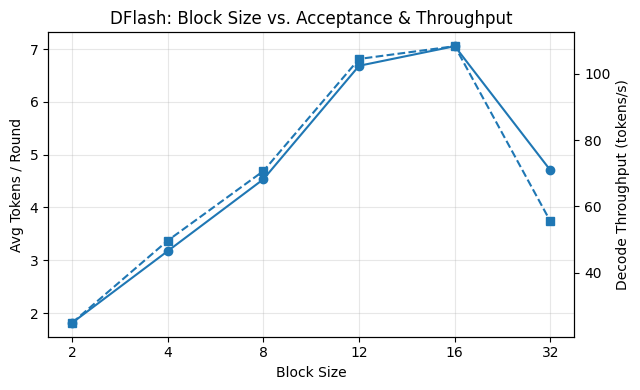

In [ ]:
# =====================================================================
# 5-5. Block Size Sweep: Avg Tokens/Round와 Decode TPS 비교
# =====================================================================

import statistics
import matplotlib.pyplot as plt

block_sizes = [2, 4, 8, 12, 16]

avg_tokens_list = []
tpss = []

for block_size in block_sizes:

  # Warm-up
  _ = dflash_generate(
    model=draft,
    target=target,
    input_ids=input_ids,
    max_new_tokens=8,
    stop_token_ids=eos_ids,
    temperature=0.0,
    block_size=block_size,
  )

  # DFlash Generation
  result = dflash_generate(
    model=draft,
    target=target,
    input_ids=input_ids,
    max_new_tokens=MAX_NEW,
    stop_token_ids=eos_ids,
    temperature=0.0,
    block_size=block_size,
    return_stats=True,
  )

  # 결과 계산
  avg_tokens = statistics.mean(result.acceptance_lengths)
  tps = 1.0 / result.time_per_output_token

  avg_tokens_list.append(avg_tokens)
  tpss.append(tps)

  print(
    f"Block Size={block_size:>2} | "
    f"Avg Tokens/Round={avg_tokens:.2f} | "
    f"Decode TPS={tps:.1f}"
  )


# =====================================================================
# Plot
# =====================================================================

x = range(len(block_sizes))

fig, ax1 = plt.subplots(figsize=(6.5, 4))

# 한 Target verification round에서 전진하는 평균 token 수
ax1.plot(x, avg_tokens_list, "o-")
ax1.set_xlabel("Block Size")
ax1.set_ylabel("Avg Tokens / Round")
ax1.set_xticks(x)
ax1.set_xticklabels(block_sizes)
ax1.grid(alpha=0.3)

# Decode Throughput
ax2 = ax1.twinx()
ax2.plot(x, tpss, "s--")
ax2.set_ylabel("Decode Throughput (tokens/s)")

plt.title("DFlash: Block Size vs. Acceptance & Throughput")
plt.tight_layout()
plt.show()

In [ ]:
import gc

del target, draft

gc.collect()
torch.cuda.empty_cache()

print(f"VRAM after cleanup: {torch.cuda.memory_allocated()/1024**3:.2f} GB")

VRAM after cleanup: 0.01 GB
